# Árboles de Decisión
## Clasificación mediante particiones del espacio

Un **Árbol de Decisión** es un modelo de clasificación que divide el espacio de características en regiones utilizando reglas simples.

En lugar de buscar una frontera lineal, el modelo crea **reglas binarias** que separan los datos.

## Idea central

El modelo aprende reglas del tipo:

si x1 < 1.7
    clase = 0
si x1 ≥ 1.7
    clase = 1

Estas reglas generan una estructura jerárquica llamada **árbol**.

Cada nodo del árbol realiza una pregunta sobre una variable.

## Cómo se construye el árbol

Durante el entrenamiento el algoritmo busca divisiones que separen mejor las clases utilizando criterios como:

- **Gini impurity**
- **Entropy (information gain)**

Estas métricas miden qué tan "puras" quedan las regiones después de dividir los datos.

## Interpretación geométrica

Los árboles de decisión dividen el espacio con **cortes paralelos a los ejes**.

Esto genera regiones **rectangulares (2D)** o **rectangulares tridimensionales (3D)**.

A diferencia de modelos lineales, el árbol puede producir **fronteras de decisión no lineales**.

## Ventajas

- Muy **interpretables**
- Funcionan con datos no lineales
- No requieren escalamiento de variables

## Limitaciones

- Pueden **sobreajustar** los datos
- Las fronteras pueden ser irregulares si el árbol crece demasiado

## Qué se observará en este notebook

1. Se cargará un dataset sintético
2. Se entrenará un **Árbol de Decisión**
3. Se evaluará el modelo en test
4. Se visualizará el comportamiento del clasificador




In [14]:
# Cell — Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [15]:
# Cell 2 — Importando módulo propio

from utils.classification_functions import *

In [16]:
# Cell 3 — Leyendo datos

DATA_FILE = "binary_classification_less_separable_3d.csv"  # cambiar aquí

data_path = Path("../data/mocked_data") / DATA_FILE
df = pd.read_csv(data_path)

X = df.drop(columns=["y"])
y = df["y"]

print(f"Dataset loaded: {DATA_FILE}")
print(f"Shape: {df.shape}")

df.head()

Dataset loaded: binary_classification_less_separable_3d.csv
Shape: (20000, 4)


,x1,x2,x3,y
0,0.243460,0.176335,-2.295278,0
1,-0.437769,1.590139,-1.343443,0
2,-1.233956,2.585832,-0.736042,0
3,-0.372753,2.354267,-0.674096,0
4,-1.181945,1.982743,-1.984979,0


In [17]:
# Cell — Train/Test split

TEST_SIZE = 0.2
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (16000, 3)
Test set: (4000, 3)


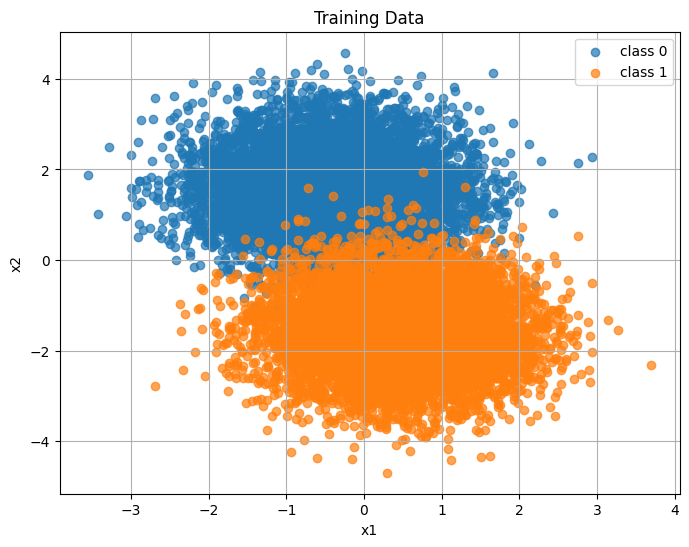

In [18]:
plot_points(
    X_train.to_numpy(),
    y_train.to_numpy(),
    dims=2,
    title="Training Data"
)

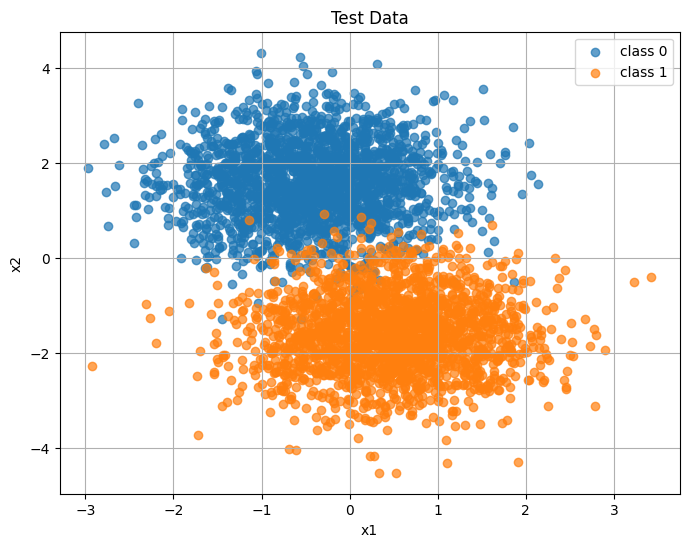

In [19]:
plot_points(
    X_test.to_numpy(),
    y_test.to_numpy(),
    dims=2,
    title="Test Data"
)

## Entrenando Árbol de Decisión

In [20]:
# Cell — Hyperparameters

TREE_PARAMS = {

    "criterion": "gini",       # "gini" o "entropy"
    "max_depth": None,         # profundidad máxima del árbol
    "min_samples_split": 2,    # mínimo de muestras para dividir
    "min_samples_leaf": 1,     # mínimo de muestras en hoja
    "random_state": RANDOM_SEED

}

In [21]:
# Cell — Training

model = DecisionTreeClassifier(**TREE_PARAMS)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [22]:
# Cell — Inspect model

clf = model

print("Tree depth:", clf.get_depth())
print("Number of leaves:", clf.get_n_leaves())
print("Feature importances:", clf.feature_importances_)

Tree depth: 15
Number of leaves: 167
Feature importances: [0.00942818 0.92614826 0.06442356]


In [23]:
clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

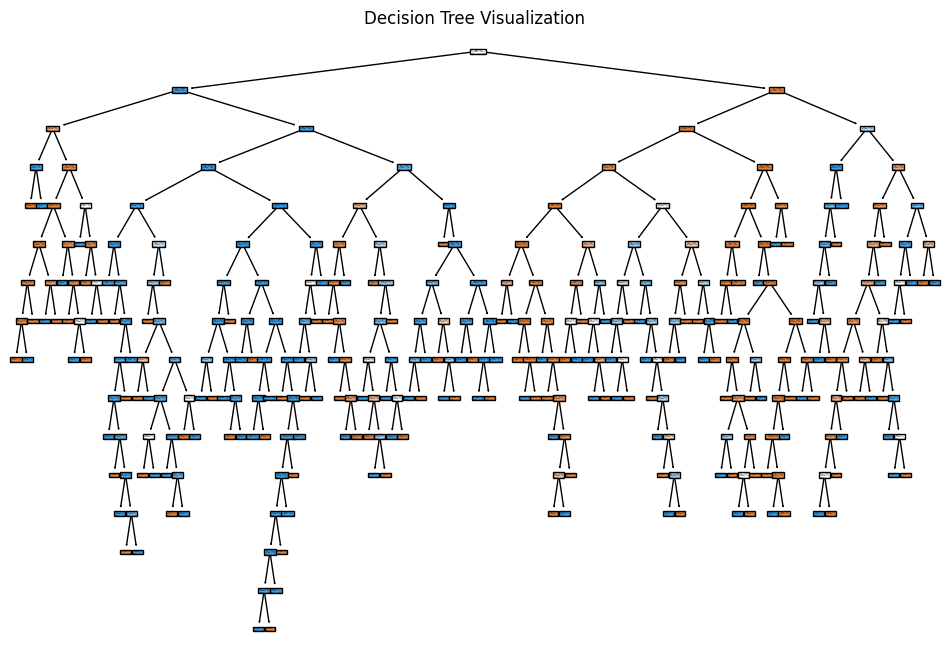

In [24]:
# Graficando el árbol (si es pequeño)
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=X.columns)
plt.title("Decision Tree Visualization")
plt.show()

Test Accuracy: 0.9885

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2000
           1       0.99      0.99      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



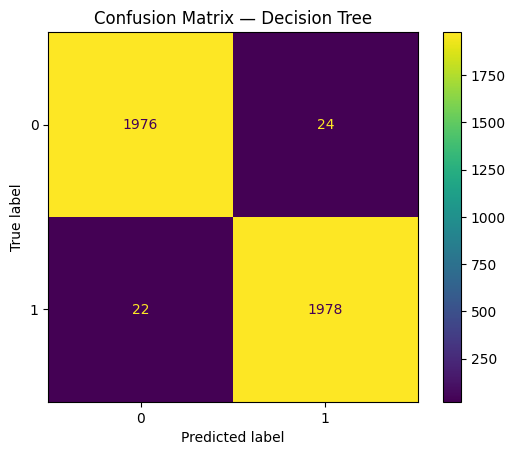

In [25]:
# Cell — Evaluation

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix — Decision Tree")

plt.show()

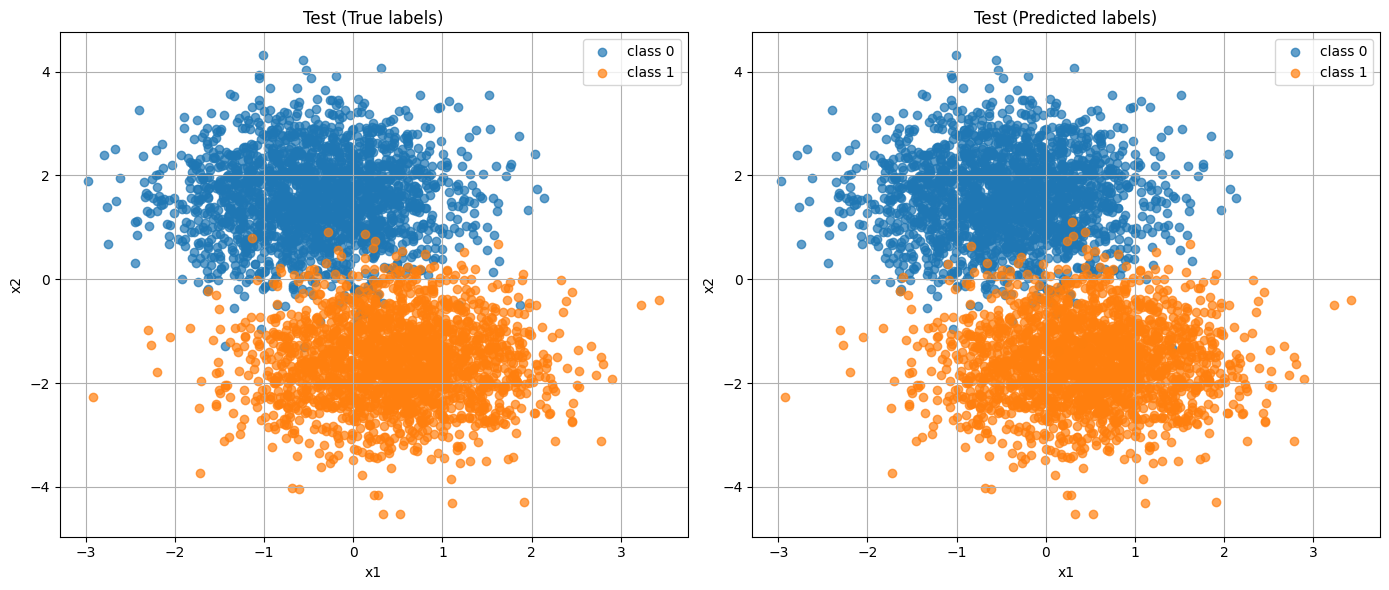

In [26]:
plot_true_vs_pred(
    X_test,
    y_test,
    y_pred,
    dims=2,
    elev=25,
    azim=45
)